<span style="font-size: 54px; font-family: 'Bauhaus 93'; font-weight: bold;">The Evolution of Gaming</span>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector
import seaborn as sns

In [4]:


#Connected to MySQL
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Catalyst@312",
    database="dagevolve"
)

cursor = conn.cursor()


cursor.execute("SELECT * FROM dagevolve_full")
rows = cursor.fetchall()


columns = [col[0] for col in cursor.description]
df = pd.DataFrame(rows, columns=columns)


df["North America_Sales"] = (
    df["North America_Sales"]
    .replace(["", "N/A", "NA", None], 0)
    .astype(float)
    .fillna(0)
    .astype(int)
)

df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Nintendo Wii,2006,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
1,Super Mario Bros.,Nintendo NES,1985,Platform,Nintendo,Home,Nintendo,1983,2003,61.91,29,3.58,6.81,40.24
2,Mario Kart Wii,Nintendo Wii,2008,Racing,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
3,Wii Sports Resort,Nintendo Wii,2009,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
4,Pokemon Red/Pokemon Blue,Gameboy,1996,Role-Playing,Nintendo,Handheld,Nintendo,1989,2003,64.42,11,8.89,10.22,31.37


<span style="font-size: 24px; font-family: 'Times New Roman'; font-weight;">

### Exploring the Database and Inspecting Table Structure
This focuses on understanding the structure of the dagevolve_full table, validating column formats, and running targeted SQL queries to prepare for deeper analysis. These exploratory steps ensure that each field is correctly typed, consistently formatted, and ready for transformation or visualization. This query removes commas, handles empty strings, and safely casts the North_America_Sales field into a numeric type for validation.</span>


In [5]:
query = """
SELECT 
    CAST(
        NULLIF(REPLACE(North_America_Sales, ',', ''), '') 
        AS UNSIGNED
    ) AS North_America_Sales,
    *
FROM dagevolve_full;
"""
df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Nintendo Wii,2006,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
1,Super Mario Bros.,Nintendo NES,1985,Platform,Nintendo,Home,Nintendo,1983,2003,61.91,29,3.58,6.81,40.24
2,Mario Kart Wii,Nintendo Wii,2008,Racing,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
3,Wii Sports Resort,Nintendo Wii,2009,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
4,Pokemon Red/Pokemon Blue,Gameboy,1996,Role-Playing,Nintendo,Handheld,Nintendo,1989,2003,64.42,11,8.89,10.22,31.37


<span style="font-size: 24px; font-family: 'Times New Roman'; font-weight;">

### The complete table is loaded into a pandas DataFrame for inspection and preprocessing.

In [6]:
cursor.execute("SELECT * FROM dagevolve_full;")
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Nintendo Wii,2006,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41.49,29.02,3.77,82.74
1,Super Mario Bros.,Nintendo NES,1985,Platform,Nintendo,Home,Nintendo,1983,2003,61.91,29.08,3.58,6.81,40.24
2,Mario Kart Wii,Nintendo Wii,2008,Racing,Nintendo,Home,Nintendo,2006,2013,101.63,41.49,29.02,3.77,82.74
3,Wii Sports Resort,Nintendo Wii,2009,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41.49,29.02,3.77,82.74
4,Pokemon Red/Pokemon Blue,Gameboy,1996,Role-Playing,Nintendo,Handheld,Nintendo,1989,2003,64.42,11.27,8.89,10.22,31.37


<span style="font-size: 24px; font-family: 'Times New Roman'; font-weight;">To understand the structure of the dataset—including column names, data types, and nullability—the table schema is retrieved using DESCRIBE.
This step is required for identifying fields that require cleaning, type conversion, or normalization.

In [5]:
cursor.execute("DESCRIBE dagevolve_full;")
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])#  
df.head(15)

,Field,Type,Null,Key,Default,Extra
0,Game Title,text,YES,,None,
1,Console,varchar(50),YES,MUL,None,
2,Year,int,YES,,None,
3,Genre,text,YES,,None,
4,Game_Company,varchar(255),YES,,None,
5,Type,text,YES,,None,
6,Console_Company,text,YES,,None,
7,Console Release Year,int,YES,,None,
8,Console Disco Year,int,YES,,None,
9,Consoles sold (million),double,YES,,None,


In [6]:
import pandas as pd

cursor.execute("SELECT * FROM dagevolve_full ORDER BY Game_Company ASC;")
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])#
df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


<span style="font-size: 24px; font-family: 'Times New Roman'; font-weight;">Focused queries help isolate key variables—such as Genre and Global_Sales—for exploratory visualizations and statistical summaries.

In [7]:
query = """
    SELECT Genre, Global_Sales
    FROM dagevolve_full
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]
genre_sales = pd.DataFrame(rows, columns=cols)


In [9]:
import pandas as pd

df_vgsales = pd.DataFrame(rows, columns=cols)
df_vgsales.head()


,Genre,Global_Sales
0,Sports,82.74
1,Platform,40.24
2,Racing,82.74
3,Sports,82.74
4,Role-Playing,31.37


<span style="font-size: 22px; font-family:'Times New Roman'; font-weight:;">

#### This bar chart highlights the total global sales for each video-game genre and emphasizes the top-performing category using a custom color palette. The chart is designed for clarity, accessibility, and presentation-ready storytelling, with clean gridlines, internal labels, and a modern aesthetic.</span>

<span style="font-size: 22px; font-family:'Times New Roman'; font-weight:;">

### This Chart Shows
- Total global sales by genre, sorted from highest to lowest.
- The top-performing genre is highlighted using a contrasting teal-blue accent.
- Internal labels make it easy to compare values without relying solely on the axis.
- Clean gridlines and reduced borders create a modern, presentation-ready look.
- Rotated x-axis labels ensure readability even with long genre names.


### This bar chart provides a clear, data-driven view of which genres dominate the global market. It supports deeper analysis by helping identify:
- Market-leading genres
- Potential growth opportunities
- Shifts in consumer preferences
- Areas for further segmentation or regional comparison

</span>


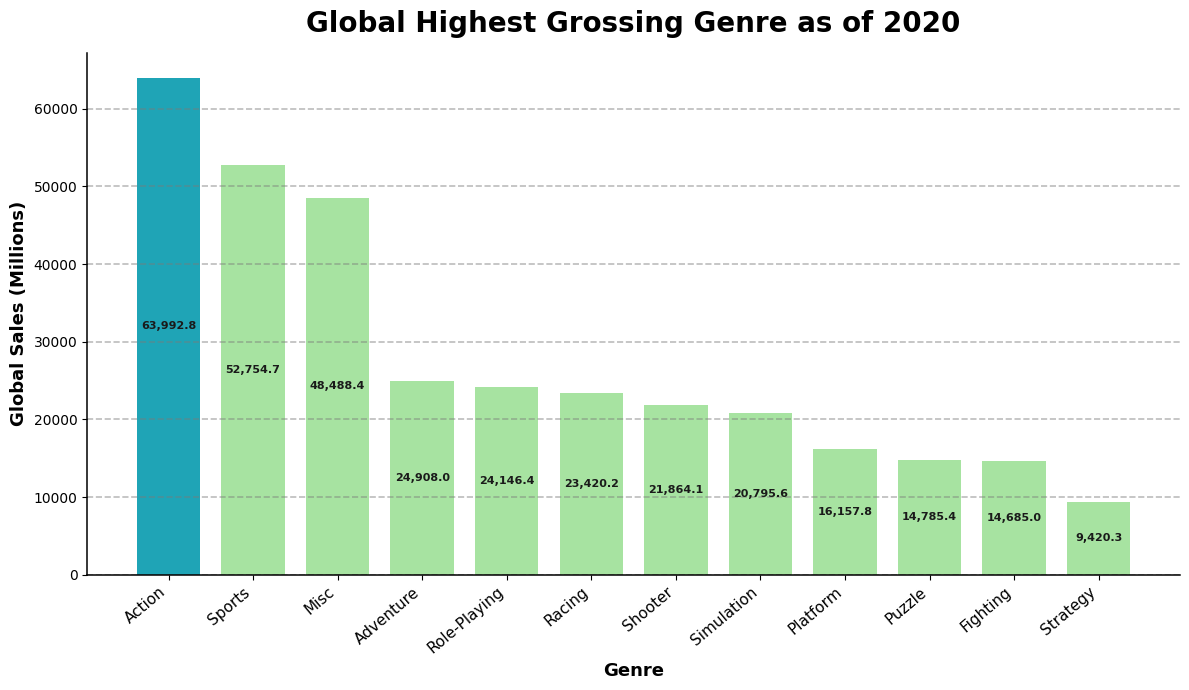

In [10]:
import matplotlib.pyplot as plt

Genre = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

base_color = "#A7E3A1"        
highlight_color = "#1FA4B6"   

colors = [base_color] * len(Genre)

max_index = Genre.idxmax()
highlight_position = Genre.index.get_loc(max_index)
colors[highlight_position] = highlight_color

bars = plt.bar(Genre.index, Genre.values, color=colors, width=0.75)

for i, value in enumerate(Genre.values):
    plt.text(
        i,
        float(value) * 0.50,
        f"{value:,.1f}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#1A1A1A"
    )


plt.gca().yaxis.grid(
    True,
    linestyle="--",
    linewidth=1.2,
    alpha=0.5,
    color="#7A7A7A"
)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)

plt.title("Global Highest Grossing Genre as of 2020", fontsize=20, fontweight="bold", pad=15)
plt.xlabel("Genre", fontsize=13, fontweight="bold")
plt.ylabel("Global Sales (Millions)", fontsize=13, fontweight="bold")

plt.xticks(rotation=40, ha="right", fontsize=11)

plt.tight_layout()
plt.show()


In [12]:
query = """
    SELECT Game_Company, Global_Sales
    FROM dagevolve_full
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
df_vgsales = pd.DataFrame(rows, columns=cols)
df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


<span style="font-size: 22px; font-family:'Times New Roman'; font-weight:;">

### This horizontal bar chart highlights the ten companies with the highest global sales, using a horizontal bar chart for clear comparison. Each bar includes an internal label showing the total sales value, and the chart uses a clean, modern style with gridlines and inverted ordering for readability.<br>
#### This Chart Shows
- The top 10 companies ranked by total global sales.
- A horizontal layout that makes long company names easier to read.
- Internal labels that display exact sales values for quick comparison.
- A clean grid and inverted axis to emphasize the highest performers at the top.
This chart pairs well with your genre and platform visualizations, helping build a complete picture of which companies dominate the global gaming market.


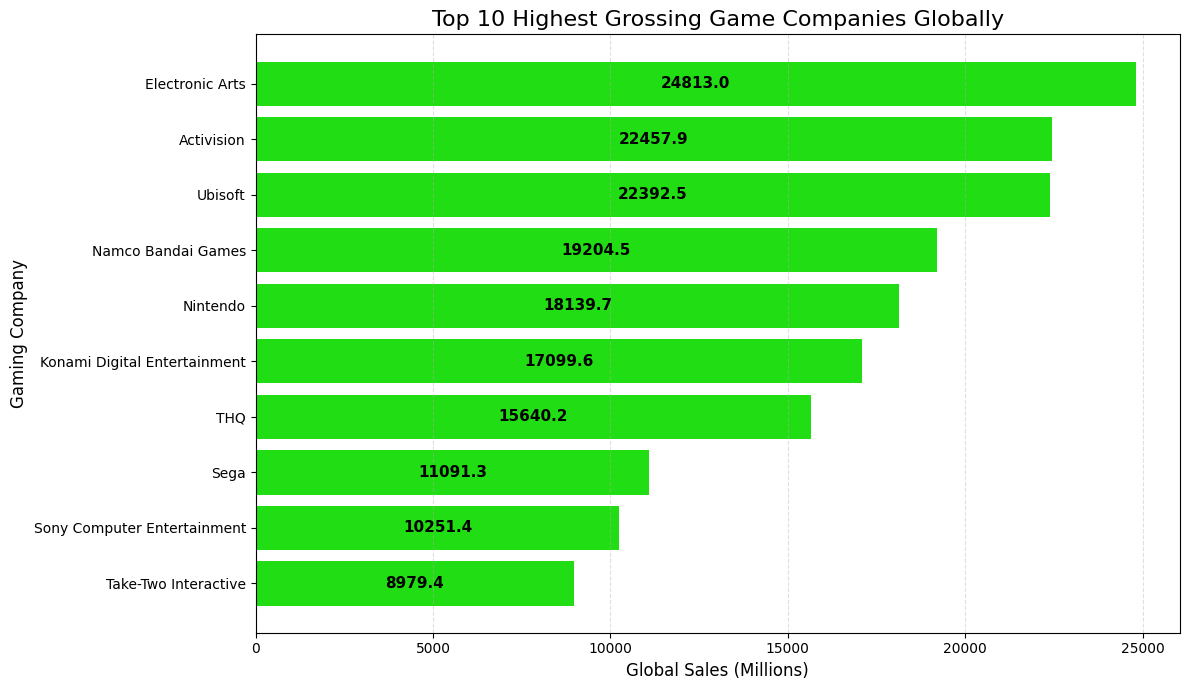

In [13]:
import matplotlib.pyplot as plt

Company_sales = (
    df_vgsales.groupby("Game_Company")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

plt.barh(
    Company_sales["Game_Company"],
    Company_sales["Global_Sales"],
    color="#21dd13"
)


for i, value in enumerate(Company_sales["Global_Sales"]):
    plt.text(
        value / 2,                      
        i,                             
        f"{value:.1f}",              
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

plt.title("Top 10 Highest Grossing Game Companies Globally", fontsize=16)
plt.xlabel("Global Sales (Millions)", fontsize=12)
plt.ylabel("Gaming Company", fontsize=12)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()



In [14]:
query = """
SELECT
    Console,
    Global_Sales,

    Japan_Sales,
    Europe_Sales
FROM dagevolve_full;
"""

cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

df_vgsales = pd.DataFrame(rows, columns=cols)
df.head()


,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


In [15]:
df = df.rename(columns={
    "North_America_Sales": "North America_Sales"
})


<span style="font-size: 22px; font-family:'Times New Roman'; font-weight:;">

### Stacked Bar Chart of Console Sales by Region compares the top gaming consoles across North America, Europe, and Japan using a stacked bar chart. Each segment of the bar represents regional sales, with labels placed inside each colored section for clarity.<br>


#### This Chart Highlights
- A stacked comparison of console sales across three major regions.
- Clear internal labels showing exact sales values for each region.
- A clean, readable layout with gridlines and rotated labels.
- A consolidated view of how each console performs globally by region.
This chart pairs well with your earlier regional and global analyses, helping show how each console’s success varies across markets.


In [16]:
sql = """
SELECT 
    na.Console,
    (na.North_America_Sales 
     + eu.Europe_Sales 
     + jp.Japan_Sales) AS Global_Sales
FROM na_sales AS na
JOIN eu_sales AS eu
    ON na.Console = eu.Console
JOIN jp_sales AS jp
    ON na.Console = jp.Console
ORDER BY Global_Sales DESC
LIMIT 10;
"""

<span style="font-size: 22px; font-family:'Times New Roman'; font-weight:;">

### Top 10 Global Console Sales <br>
#### This Line Plot highlights the top 10 gaming consoles by global sales, using a clean line plot to emphasize trends across platforms. The plot uses your signature green (#2E7D32), strong line weights, and circular markers for clarity and visual consistency with your dashboard style.

#### This Plot Shows
- Console (x‑axis): Each gaming console included in the top 10 ranking
- Global Sales (y‑axis): Total worldwide sales in millions
- Line + markers: Highlights both the trend and individual data points
- Horizontal gridlines: Improve readability and comparison across consoles
- Uses your preferred minimalist white theme
- Applies your signature green for brand consistency
- Ensures high readability with rotated labels and clean spacing
- Maintains a presentation‑ready aesthetic suitable for dashboards or portfolio work



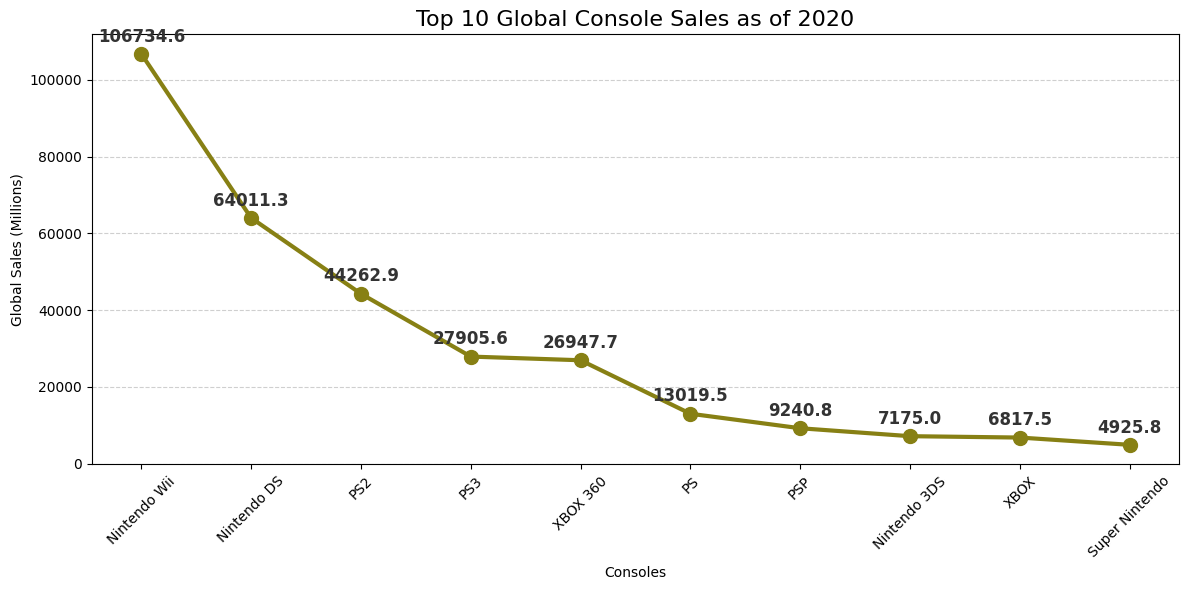

In [17]:
# Create top10_df from the console sales data
top10_df = (
    df.groupby("Console")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Convert Decimal to float
top10_df["Global_Sales"] = top10_df["Global_Sales"].astype(float)

plt.figure(figsize=(12, 6))

plt.plot(
    top10_df["Console"],
    top10_df["Global_Sales"],
    color="#878014",
    linewidth=3,
    marker="o",
    markersize=10
)

for x, y in zip(top10_df["Console"], top10_df["Global_Sales"]):
    plt.text(
        x,
        y + (max(top10_df["Global_Sales"]) * 0.03), 
        f"{y:.1f}",
        ha="center",
        fontsize=12,
        color="#333333",
        fontweight="bold"
    )

plt.title("Top 10 Global Console Sales as of 2020", fontsize=16)
plt.xlabel("Consoles")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


<span style="font-size: 22px; font-family:'Times New Roman'; font-weight:;">

#### This step retrieves the total sales by region—North America, Europe, and Japan—using a UNION‑based SQL query. The results are then loaded into a pandas DataFrame for further analysis or visualization.


In [18]:
query = """
SELECT 
    'North America' AS Region,
    SUM(`North America_Sales`) AS Total_Sales
FROM dagevolve_full
UNION ALL

SELECT 
    'Europe' AS Region,
    SUM(Europe_Sales) AS Total_Sales
FROM dagevolve_full
UNION ALL

SELECT 
    'Japan' AS Region,
    SUM(Japan_Sales) AS Total_Sales
FROM dagevolve_full;
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]
df_region_sales = pd.DataFrame(rows, columns=cols)
df.head()


,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


<div style="font-family:'Times New Roman'; font-size:22px; font-weight:400;">

### This pie chart is showing the share of total video-game sales across North America, Europe, and Japan. The chart uses pastel colors, percentage labels, and a slight “explode” effect to highlight the lowest-performing region.

#### What This Chart Shows
- The percentage share of total sales for each region.
- A pastel color palette for a clean, presentation-ready look.
- A small explode effect to draw attention to the region with the lowest revenue.
- A simple, high-level comparison of market size across regions. The same dataset can be reused for bar charts or stacked comparisons.

</div>



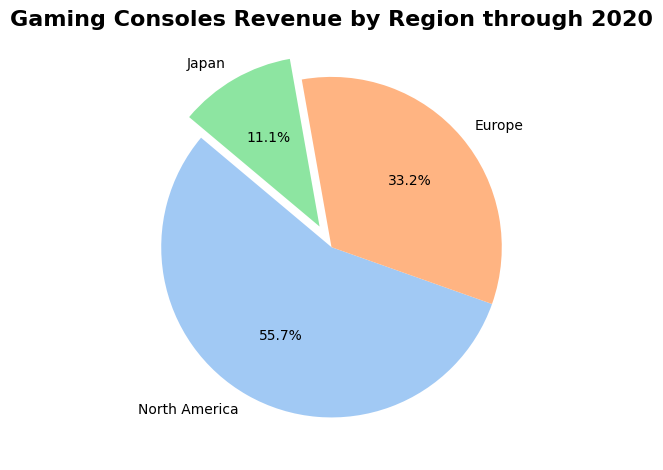

In [19]:
plt.pie(
    df_region_sales["Total_Sales"],
    labels=df_region_sales["Region"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel", len(df_region_sales)),
    explode = [0, 0, 0.14]  
)

plt.title("Gaming Consoles Revenue by Region through 2020", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

<div style="font-family:'Times New Roman'; font-size:22px; font-weight:400;">

### This section retrieves company-level console sales from the database, loads the results into a pandas DataFrame, and identifies the top 10 companies based on total units sold.

#### What This Does
- Extracts Game_Company and Consoles sold (million) from the dataset.
- Loads the results into a DataFrame for analysis.
- Aggregates and ranks companies by total console sales.
- Produces a clean table of the top 10 highest-selling companies.



In [20]:
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Catalyst@312",
    database="dagevolve"
)

cursor = conn.cursor()

cursor.execute("SELECT * FROM dagevolve_full")
rows = cursor.fetchall()


In [21]:
query = """
SELECT Game_Company, `Consoles sold (million)`
FROM dagevolve_full
"""

cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
df_vgsales = pd.DataFrame(rows, columns=cols)


In [22]:
top_companies = (
    df_vgsales.groupby("Game_Company")["Consoles sold (million)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_companies


,Game_Company,Consoles sold (million)
0,Electronic Arts,105494.70
1,Namco Bandai Games,86282.93
2,Activision,80282.61
3,Ubisoft,78947.38
4,Konami Digital Entertainment,77890.84
5,Sony Computer Entertainment,74081.72
6,THQ,58361.16
7,Nintendo,49464.33
8,Sega,45897.78
9,Take-Two Interactive,35258.06


<span style="font-size: 22px; font-family:'Times New Roman'; font-weight:;">

### This shows the comparison of console sales across the top gaming companies.<br>

#### The bar chart highlights the company with the highest units sold using a distinct violet shade, while all remaining companies appear in a lighter purple tone for contrast and readability.<br>

- Matplotlib and Seaborn are used to build a horizontal bar chart.

##### The script:
- Calculates the maximum units sold.
- Applies custom colors:
- Violet (#7F00FF) for the highest value.
- Light purple (#C9A8FF) for all others.
- Adds centered numeric labels inside each bar.
- Uses a clean grid and layout for presentation‑ready output



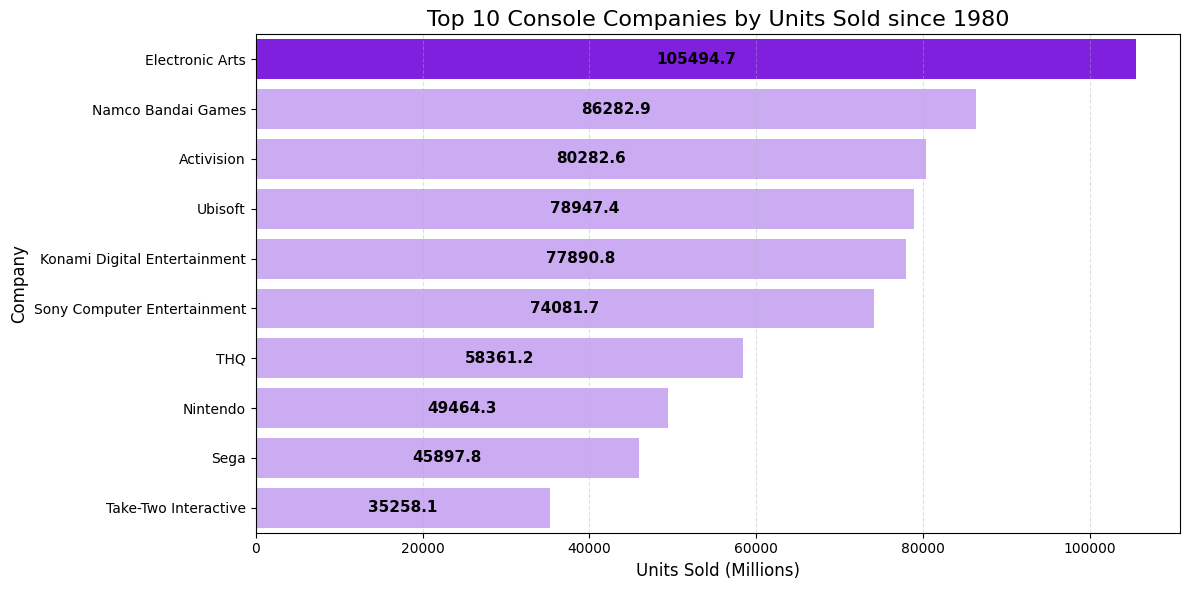

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

max_value = top_companies["Consoles sold (million)"].max()


colors = [
    "#7F00FF" if value == max_value else "#C9A0FF"
    for value in top_companies["Consoles sold (million)"]
]

sns.barplot(
    data=top_companies,
    x="Consoles sold (million)",
    y="Game_Company",
    hue="Game_Company",
    palette=colors,
    legend=False
)


for i, value in enumerate(top_companies["Consoles sold (million)"]):
    plt.text(
        value / 2,
        i,
        f"{value:.1f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

plt.title("Top 10 Console Companies by Units Sold since 1980", fontsize=16)
plt.xlabel("Units Sold (Millions)", fontsize=12)
plt.ylabel("Company", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()







<div style="font-family:'Times New Roman'; font-size:26px; font-weight:;">

### Most Popular Console Types by Decade

This chart shows how different console types evolved in popularity across multiple decades. Using a pivoted dataset, the chart compares Handheld, Home, and Home Console Add‑On categories, highlighting shifts in gaming trends over time.
The grouped bar chart is generated with Matplotlib, and numeric labels are added directly above each bar to improve readability and support quick interpretation.

- Home consoles dominate the 2000s, reaching their highest recorded count.
- Handheld consoles show strong performance in the 2000s and 2010s.
- Add‑on consoles remain minimal across all decades.
- The numeric labels provide immediate insight into category magnitude without needing to reference the axis scale.


In [24]:
query = """
WITH decade_groups AS (
    SELECT
        Type,
        CASE
            WHEN Year BETWEEN 1990 AND 1999 THEN '1990s'
            WHEN Year BETWEEN 2000 AND 2009 THEN '2000s'
            WHEN Year BETWEEN 2010 AND 2019 THEN '2010s'
            WHEN Year BETWEEN 2020 AND 2029 THEN '2020s'
        END AS Decade
    FROM dagevolve_full
    WHERE Year IS NOT NULL
    AND Type IS NOT NULL
)
SELECT
    Decade,
    Type,
    COUNT(*) AS Type_Count
FROM decade_groups
WHERE Decade IS NOT NULL
GROUP BY Decade, Type
ORDER BY Decade, Type_Count DESC;
"""


df.head()


,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


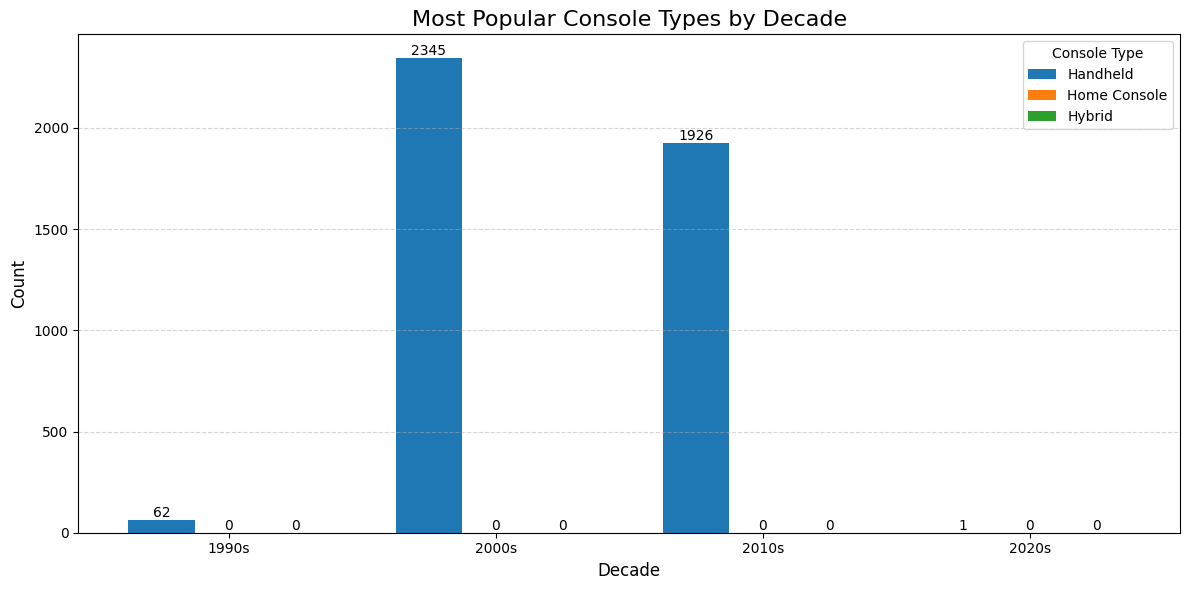

In [33]:
types = ["Handheld", "Home Console", "Hybrid"]

# Plot
plt.figure(figsize=(12, 6))

for i, t in enumerate(types):
    bars = plt.bar(x + i*width, pivot_df[t], width, label=t)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.xticks(x + width, decades)
plt.title('Most Popular Console Types by Decade', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Console Type')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
